# Blind numerical transfer of equivalent steep area

This notebook reads only the frozen outputs from issue #15. Four regions and one inventory-defined window per region were selected by hash before terrain values were opened. The calculation tests numerical resolution and phase transfer; it does not validate susceptibility, event incidence, or a global terrain distribution.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
long = pd.read_csv(ROOT / 'data/scale_explicit_transfer/equivalent_area_long.csv', dtype={'region': str})
decisions = pd.read_csv(ROOT / 'data/scale_explicit_transfer/decisions.csv', dtype={'region': str})
overall = pd.read_csv(ROOT / 'data/scale_explicit_transfer/overall_decision.csv')
assert len(long) == 40 and len(decisions) == 8
assert overall.transfer_gate_pass.tolist() == ['yes'] and decisions.window_pass.eq('yes').all()

In [2]:
shown = decisions[['region', 'stratum', 'reference_equivalent_area_m2', 'departure_90m', 'phase_cv', 'window_pass']].copy()
shown.reference_equivalent_area_m2 /= 1e6
shown.departure_90m *= 100
shown.phase_cv *= 100
shown.columns = ['region', 'stratum', '$E_0$ (km$^2$)', '$D_{90}$ (%)', 'phase CV (%)', 'pass']
display(shown.round(4))
print('All eight window-stratum checks pass the registered numerical transfer gate.')

,region,stratum,$E_0$ (km$^2$),$D_{90}$ (%),phase CV (%),pass
0,04,glacier_proximity,1.4652,3.1896,0.3752,yes
1,04,permafrost,124.2721,1.8135,0.0760,yes
2,10,glacier_proximity,2.8081,2.4183,0.3013,yes
3,10,permafrost,289.0479,4.1105,0.0061,yes
4,15,glacier_proximity,15.5013,2.4506,0.1712,yes
5,15,permafrost,297.4209,1.9084,0.0650,yes
6,18,glacier_proximity,8.2131,2.7137,0.1256,yes
7,18,permafrost,0.5211,5.2789,0.1688,yes


All eight window-stratum checks pass the registered numerical transfer gate.


## Complete blind-window result

The upper panels show all five calculated variants. The lower panel divides each diagnostic by its registered bound, so the dashed line is the acceptance threshold.

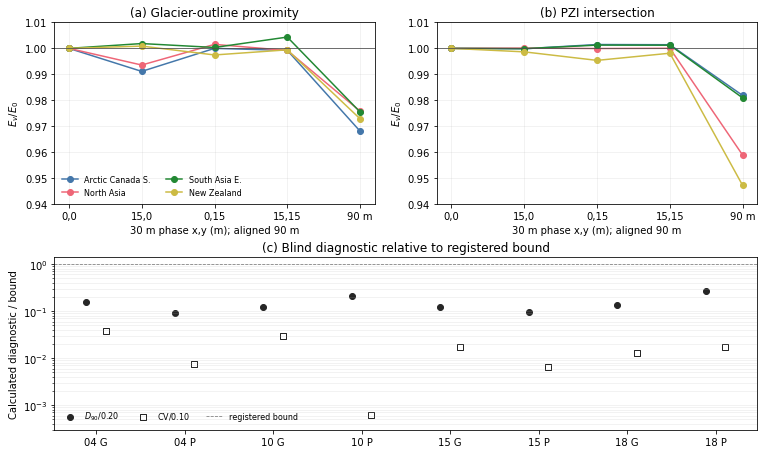

In [3]:
regions = ['04', '10', '15', '18']
names = {'04': 'Arctic Canada S.', '10': 'North Asia', '15': 'South Asia E.', '18': 'New Zealand'}
colors = dict(zip(regions, ['#4477AA', '#EE6677', '#228833', '#CCBB44']))
variants, labels = ['p00', 'p10', 'p01', 'p11', 'r90'], ['0,0', '15,0', '0,15', '15,15', '90 m']
fig = plt.figure(figsize=(10.5, 6.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[1, 0.95])
axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]), fig.add_subplot(grid[1, :])]
for ax, stratum, title in zip(axes[:2], ['glacier_proximity', 'permafrost'], ['(a) Glacier-outline proximity', '(b) PZI intersection']):
    for region in regions:
        values = long[(long.region == region) & (long.stratum == stratum)].set_index('variant').loc[variants].area_ratio
        ax.plot(labels, values, 'o-', color=colors[region], label=names[region])
    ax.axhline(1, color='0.3', lw=0.8)
    ax.set(title=title, xlabel='30 m phase x,y (m); aligned 90 m', ylabel='$E_v/E_0$', ylim=(0.94, 1.01))
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False, fontsize=8, ncol=2)
x = np.arange(len(decisions))
axes[2].scatter(x - 0.11, decisions.departure_90m / decisions.reference_departure_bound, marker='o', color='0.15', label='$D_{90}/0.20$')
axes[2].scatter(x + 0.11, decisions.phase_cv / decisions.reference_phase_cv_bound, marker='s', facecolor='none', edgecolor='0.15', label='CV$/0.10$')
axes[2].axhline(1, color='0.5', ls='--', lw=0.8, label='registered bound')
axes[2].set_yscale('log')
axes[2].set(title='(c) Blind diagnostic relative to registered bound', ylabel='Calculated diagnostic / bound', xticks=x,
            xticklabels=[f"{row.region} {'G' if row.stratum == 'glacier_proximity' else 'P'}" for row in decisions.itertuples()], ylim=(3e-4, 1.4))
axes[2].grid(axis='y', alpha=0.2, which='both'); axes[2].legend(frameon=False, fontsize=8, ncol=3)
for suffix in ('png', 'pdf'):
    fig.savefig(ROOT / f'figures/scale_explicit_transfer.{suffix}', dpi=220 if suffix == 'png' else None, bbox_inches='tight')
plt.show()